# <a href="https://thetahat.ru/courses/ad">Введение в анализ данных</a>
## Домашнее задание 9. Условные распределения


**Правила, <font color="red">прочитайте внимательно</font>:**

1. Общее

     * Выполненную работу **в формате `ipynb`** нужно отправить по ссылке "Сдача ДЗ" на <a href="https://thetahat.ru/courses/ad"><b>странице курса</b></a>. **Работы, присланные иным способом, не принимаются.** Дедлайны указаны в боте и на сайте, они являются строгими.
     
     * Обязательно изучите <a href="https://thetahat.ru/courses/design-hw"><b>руководство по оформлению ДЗ</b></a>. В частности, оно содержит примеры случаев, когда могут быть снижены баллы.
     
     * Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
     
     * Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания (в т.ч. злоупотребление ИИ) всем участникам списывания дается штраф -3 скор-балла к итоговой оценке.**
     
     * Решение теоретических задач оформляйте в markdown-ячейках формате $\LaTeX$. При решении можно использовать ИИ-инструменты только для оформления написанного самостоятельно решения. Например, написать черновик формул и попросить ИИ оформить эти формулы в $\LaTeX$.
     
     * Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
     </br>

2. Правила заполнения ноутбука

     * Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения существующих ячеек.
     * Отвечайте на вопросы, а также добавляйте новые ячейки в любом количестве в предложенных местах, которые обозначены `<...>`.
     * Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз. Комментарии к решению пишите в markdown-ячейках.
     * Условия <font color="red"><b>запрещается модифицировать</b></font>.
     * При нарушении данных правил работа может получить 0 баллов.
</br>


**Баллы за задание**

* Задача 1 &mdash; 40 баллов
* Задача 2 &mdash; 50 баллов
* Задача 2 &mdash; 40 баллов

In [ ]:
# Bot check

# HW_ID: fpmi_ad9
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [ ]:
import numpy as np
import pandas as pd

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. ссылка
    - для чего использована
    - для чего использована
2. ссылка
    - для чего использована

**Задача 2**
1. ссылка
    - для чего использована


---
### Задача 1.


Рассмотрим датасет Breast Cancer Wisconsin Diagnostic. Это медицинский датасет про диагностику рака молочной железы. Он был собран в начале 1990-х годов в University of Wisconsin Hospitals: пациенткам с подозрительными уплотнениями в груди проводилась тонкоигольная аспирационная биопсия (FNA), полученный материал фотографировался под микроскопом, и с оцифрованных изображений автоматически выделялись границы клеточных ядер, по ним вычислялись геометрические характеристики. Итоговая версия содержит 569 образцов (212 злокачественных, 357 доброкачественных) и 30 числовых признаков.

Каждое наблюдение — это один опухолевый образец. Для каждого ядра клетки на снимке измеряются 10 базовых характеристик, а затем по всем ядрам образца считаются три агрегата:
* среднее (`mean`),
* «худшее»/максимальное из трёх наибольших значений (`worst`),
* стандартная ошибка (`error`).

Так получаются 30 признаков. Рассмотрим три из них:
* `mean area` — средняя площадь ядра;
* `mean radius` — средний радиус ядра клетки, то есть среднее расстояние от центра ядра до точек на его границе (в пикселях);
* `mean concavity` — средняя выраженность вогнутых участков контура ядра (насколько глубоко граница «заходит внутрь»);

Загрузим данные

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
from sklearn.datasets import load_breast_cancer

df = load_breast_cancer(as_frame=True).frame
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Исследуйте корреляцию между всеми парами рассматриваемых трех признаков.

In [51]:
target_features = ['mean area', 'mean radius', 'mean concavity']
data = df[target_features]

corr_matrix = data.corr()
corr_matrix

,mean area,mean radius,mean concavity
mean area,1.000000,0.987357,0.685983
mean radius,0.987357,1.000000,0.676764
mean concavity,0.685983,0.676764,1.000000


Теперь исследуйте частичную корреляцию для этих признаков

In [17]:
def partial_corr(df: pd.DataFrame, x: str, y: str, covars: list[str]) -> float:
  """
  Вычисляет частную корреляцию между x и y при фиксированных ковариатах через остатки

  Аргументы:
    df: DataFrame с исходными данными
    x: Название столбца первой переменной
    y: Название столбца второй переменной
    covars: Список названий столбцов фиксируемых ковариат.

  Возвращает:
    Значение частной корреляции между x и y.
  """

  X = df[covars].astype(float).values
  X = np.column_stack([np.ones(len(X)), X])

  def resid(v):
    b, *_ = np.linalg.lstsq(X, v, rcond=None)
    return v - X.dot(b)

  rx = resid(df[x].astype(float).values)
  ry = resid(df[y].astype(float).values)
  return np.corrcoef(rx, ry)[0, 1]

print("Частичная корреляция mean area и mean radius", round(partial_corr(data, 'mean area', 'mean radius', ['mean concavity']), 4))
print("Частичная корреляция mean area и mean concavity", round(partial_corr(data, 'mean area', 'mean concavity', ['mean radius']), 4))
print("Частичная корреляция mean radius и mean concavity", round(partial_corr(data, 'mean radius', 'mean concavity', ['mean area']), 4))


Частичная корреляция mean area и mean radius 0.9765
Частичная корреляция mean area и mean concavity 0.1523
Частичная корреляция mean radius и mean concavity -0.0047


Можете ли вы **только лишь по данным** установить, какой из признаков является причиной, а какой &mdash; следствием? Сможет ли это сделать только по этим данным сколько угодно умная нейросеть?

Нет. Никакая, даже очень умная нейросеть не сможет восстановить полный причинно-следственный граф исключительно по данным без доп предположений.
- С -> A -> R и R -> A -> C могут быть порождены так, что коэффиценты корреляций будут одинаковы.

Можно сказать, что `mean radius` и `mean concavity` зависят друг от друга.  Но они зависят именно через `mean area`, если его зафиксировать, то `mean radius` и `mean concavity` становятся линейно независимыми(корреляция падает до  -0.0047).

Отсутствие корреляции между `radius` и `concavity` делает нелогичным стрелку между ними.
Тогда в обозначениях R - `radius`, A - `area`, C - `concavity` возможны варианты:
- C -> A -> R
- R -> A -> C
- A -> C, R
- R, C -> A

Далее можно понять, что R, C -> A строго исключается», так как при фиксации A должна появиться корреляция между R и С, но ее нет.
Остаются:
- C -> A -> R
- R -> A -> C
- A -> C, R

Но дальнейший анализ затруднителен. Пример из жизни. Есть стальной шар. Он тяжелый потому что большой или большой потому что тяжелый? Тут нет причино следственной связи, только корреляция.

Так и в нашем примере.
Corr(`radius`, `concavity`| `area`) $\approx$ 0
А $corr(Area, Concavity \mid Radius) \approx 0.15$. Посмотрев на эти данные, можно сделать вывод, что `area` содержит просто больше информации(площадь - это двумерная величина, а радиус - линейная и клетка — не идеальный круг, площадь учитывает изрезанность контура), чем `radius`, хотя они почти полностью коррелированы. Логично предположить, что причино следственной связи тут вообще нет.

Можете ли вы установить, какой из признаков является причиной, а какой &mdash; следствием, опираясь на свои представления о природе данных?

Из базовых знаний геометрии, что при увелицении площади увеличивается и радиус.

**Ответ GPT на вопрос про то, что же такое вогнутость**

Если ядро имеет форму идеального круга или эллипса, его граница всегда «выгнута» наружу. Однако в патологических состояниях (например, при раке) ядра клеток часто становятся деформированными, и на их контуре появляются углубления, впадины или «вмятины».

**Конец ответа**

Я бы предположил, что при больших размерах опухоли появляются вмятины и `concavity` растет.
Откуда несложно предположить такую причинно-следственную связь:
Т.е $\{\text{радиус, вогнутость}\} \leftarrow \text{площадь}$
Это ложится на данные. При фиксации площади, нет корреляции между радиусом и вогнутостью(корреляция очень мала, -0.0047).

Выводы:

- По корреляциям нельзя делать вывод о причино сделедственных связях
- Фиксация `mean area` делает радиус и вогнутость линейно почти не зависимыми. Т.е линейная связь между радиусом и вогнутостью объясняется площадью.
- причинно следственной связи нет между метриками. Вероятно есть скрытая переменная(например, стадию роста клетки или её истинный размер), задающая эти параметры.

---
### Задача 2.

**1.** Пусть $X$ и $Y$ — случайные величины, причём $\mathsf{E} Y^2 < \infty$. Докажите формулу полной дисперсии
$$\mathsf{D} Y \;=\; \mathsf{E}\big[\mathsf{D}(Y\,|\,X)\big] \;+\; \mathsf{D}\big[\mathsf{E}(Y\,|\,X)\big].$$

<details>
<summary> ➡️ Если в твоем курсе теории вероятностей еще не было условных мат. ожиданий, кликни сюда </summary>
Тебе могут помочь следующие формулы:
    
1. Условная дисперсия определяется через условные математические ожидания $$\mathsf{D}(Y\mid X) = \mathsf{E}(Y^2\mid X) - \big[\mathsf{E}(Y\mid X)\big]^2.$$
    
2. Усреднение условного математического ожидания дает обычное математическое ожидание $$\mathsf{E}\big[\mathsf{E}(Y\mid X)\big] = \mathsf{E}Y.$$
</details>

$E[D(Y|X)] = E[E(Y^2|X) - (E(Y|X))^2] = E(Y^2) - E[(E(Y|X))^2]$

$D[E(Y|X)] = E[(E(Y|X))^2] - (E[E(Y|X)])^2 = E[(E(Y|X))^2] - (E(Y))^2$

Откуда $E[D(Y|X)] + D[E(Y|X)] = E(Y^2) - E[(E(Y|X))^2] + E[(E(Y|X))^2] - (E(Y))^2 =
E(Y^2) - (E(Y))^2 = D(Y)$

Замечание.
- В доказательстве используется правило башни.
$E(E(Y^2|X)) = E(Y^2)$ и $E(E(Y|X)) = E(Y)$
- $(E(Y|X))^2 <= E(Y^2|X)$, а так как $EY^2 < \infty$, то значит $E(Y^2) = E(E(Y^2|X))$, значит $(E(Y|X))^2$ корректно определено.


Пусть $X$ — это признаки группы (возраст, регион, профессия и т. п.), а $Y$ — измеряемая характеристика (таргет) внутри группы. Подробно проинтерпретируйте каждое слагаемое формулы.

Дисперсию характеристики можно посчитать зная дисперсию и матожидание этой характеристики при условии знания признаков.

Чтобы посчитать дисперсию Y мы раскладываем ее на 2 части.
- Среднее разброса внутри конкретной группы при фиксированном X по всем группам: E[D(Y|X)]
- Разброс между средними разных групп D[E(Y|X)]

**2.** На лекции был показан способ эмпирической оценки условного математического ожидания. Для тех же синтетических данных с лекции посчитайте приближенно
* условную дисперсию и отобразите ее на графике (анимацию делать не нужно),
* все компоненты формулы полной дисперсии.

Подтвердилась ли формула?

In [1]:
from typing import Callable, List, Optional, Tuple, Union

import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as sps
import seaborn as sns
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle
from scipy.integrate import quad
from scipy.stats import gaussian_kde
from sklearn.neighbors import KernelDensity

from IPython.display import HTML

np.random.seed(42)
sns.set_style("darkgrid")
sns.set(font_scale=1.3)

mpl.rcParams["animation.embed_limit"] = 50

In [2]:
def generate_data(n_samples: int = 500) -> tuple[np.ndarray, np.ndarray]:
    """
    Генерирует данные со сложной нелинейной зависимостью Y от X.

    Аргументы:
        n_samples: Количество генерируемых точек.

    Возвращает:
        Кортеж (X, Y) из отсортированных массивов признака и целевой переменной.
    """

    # X - равномерно распределенные точки на отрезке [0, 10]
    X = np.random.rand(n_samples) * 10

    # "Истинная" средняя зависимость Y от X (нелинейная)
    true_mean_func = lambda x: 2 * np.sin(x) + 0.1 * x**2

    # Гетероскедастичный шум: дисперсия шума зависит от X
    # Шум будет маленьким в начале и конце, и большим в середине
    noise_std = 0.5 + 2 * np.sin(np.pi * X / 10)

    # Генерируем Y с шумом
    Y = true_mean_func(X) + np.random.randn(n_samples) * noise_std

    # Добавляем "раздвоение" в области X от 7 до 9
    bifurcation_mask = (X > 6) & (X < 8)
    # Для половины точек в этой области "прыгаем" вверх или вниз
    bifurcation_indices = np.where(bifurcation_mask)[0]
    switch = np.random.rand(len(bifurcation_indices)) > 0.5

    Y[bifurcation_indices[switch]] += 5 * (1 - np.abs(X[bifurcation_indices[switch]] - 7) ** 2)
    Y[bifurcation_indices[~switch]] -= 5 * (1 - np.abs(X[bifurcation_indices[~switch]] - 7) ** 2)

    # Сортируем для удобства отрисовки
    sorted_indices = np.argsort(X)
    return X[sorted_indices], Y[sorted_indices]

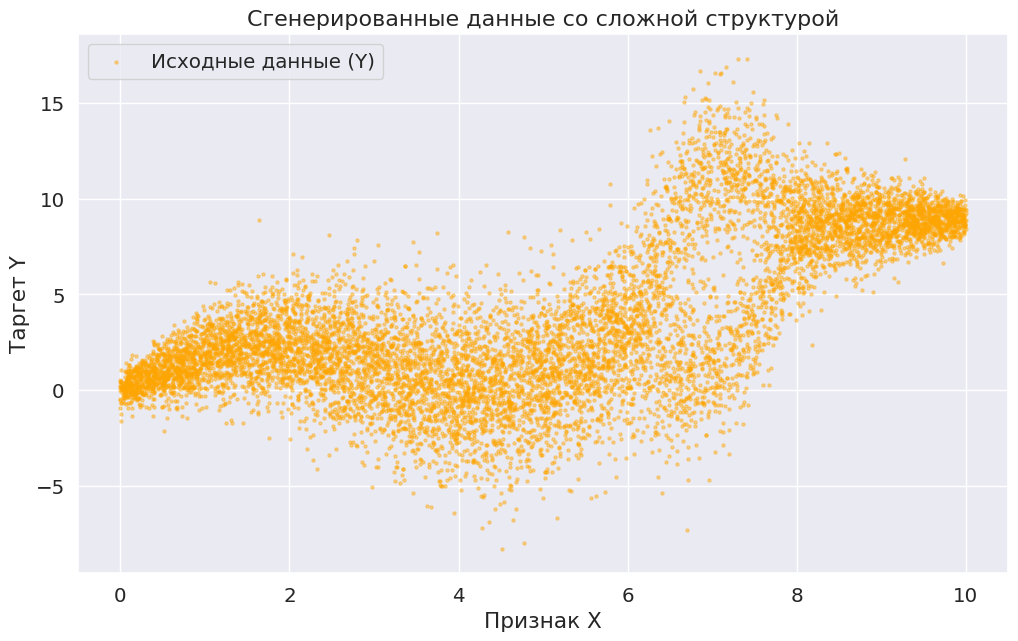

In [3]:
X, Y = generate_data(n_samples=10000)

plt.figure(figsize=(12, 7))
plt.scatter(X, Y, alpha=0.4, s=5, color="orange", label="Исходные данные (Y)")
plt.xlabel("Признак X")
plt.ylabel("Таргет Y")
plt.title("Сгенерированные данные со сложной структурой", fontsize=16)
plt.legend()
plt.show()

In [4]:
def gaussian_kernel(u: np.ndarray) -> np.ndarray:
  """
  Вычисляет значение гауссовского ядра

  Аргументы:
    u: Массив нормированных расстояний до целевой точки.

  Возвращает:
    Массив значений гауссовского ядра в точках u.
  """
  return np.exp(-0.5 * u**2) / np.sqrt(2 * np.pi)

def gaussian_kernel_regression(
    x_target:np.ndarray, X_train: np.ndarray, Y_train: np.ndarray, h: float
) -> np.ndarray:
    """
    Вычисляет оценку регрессии в точке с помощью гауссовского ядра.

    Аргументы:
        x_target: массив точек, в которых вычисляется оценка регрессии.
        X_train: Массив значений признака обучающей выборки.
        Y_train: Массив значений целевой переменной обучающей выборки.
        h: Ширина окна ядра.

    Возвращает:
        Взвешенную оценку условного математического ожидания в точке x_target или NaN,
        если сумма весов равна нулю.
    """
    # Добавим новую ось для broadcasting`a
    # Если у нас target размера (N,), то станет (N, 1)
    x_target_col = np.asarray(x_target)[:, np.newaxis]
    gaussian_kernels = gaussian_kernel((X_train - x_target_col) / h)

    weights_sum = gaussian_kernels.sum(axis=1)
    numerator = gaussian_kernels @ Y_train
    result = np.full(numerator.shape, np.nan)
    mask = weights_sum != 0
    result[mask] = numerator[mask] / weights_sum[mask]

    return result

def conditional_second_moment_regression(
    x_target: np.ndarray, X_train: np.ndarray, Y_train: np.ndarray, h: float
) -> float:
    """
    Вычисляет оценку квадрата регрессии в точке с помощью гауссовского ядра.

    Аргументы:
        x_target: массив точек, в которых вычисляется оценка регрессии.
        X_train: Массив значений признака обучающей выборки.
        Y_train: Массив значений целевой переменной обучающей выборки.
        h: Ширина окна ядра.

    Возвращает:
        Взвешенную оценку условного математического ожидания в точке x_target или NaN,
        если сумма весов равна нулю.
    """

    return gaussian_kernel_regression(x_target, X_train, Y_train ** 2, h)

Полная дисперсия D(Y): 16.9044
E[D(Y|X)]: 6.2880
D[E(Y|X)]: 10.6060
E[D(Y|X)] + D[E(Y|X)]: 16.8940
Разница (ошибка аппроксимации): 0.010391


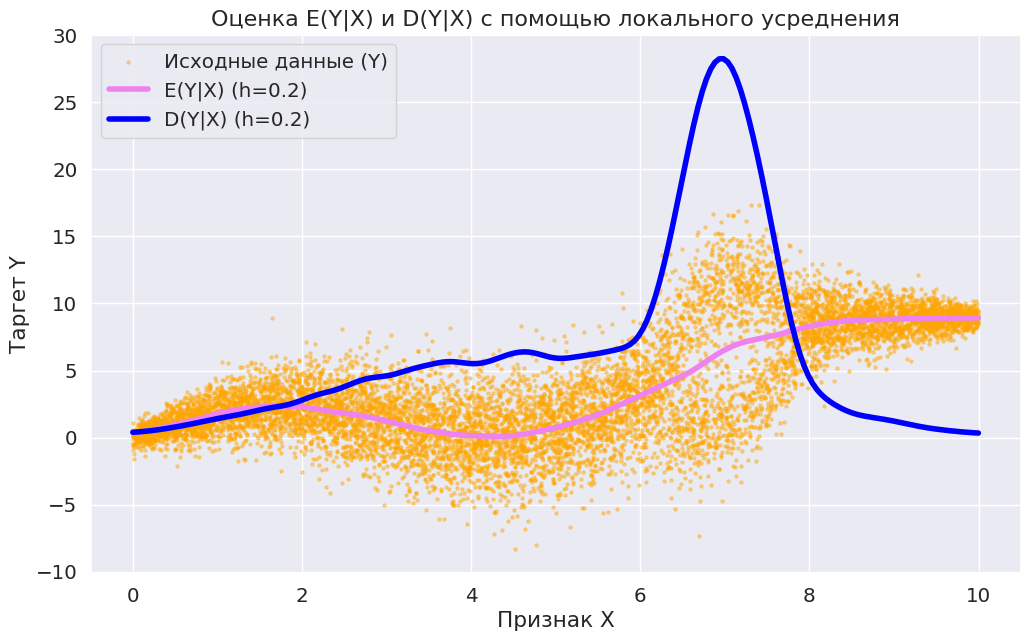

In [5]:
# Создаем сетку точек, в которых будем вычислять регрессию
x_grid = np.linspace(X.min(), X.max(), 200)
h = 0.2 # Берем небольшой h для сглаживания

# Считаем на равномерной сетке для отрисовки графиков
E_Y_X_grid = np.array(gaussian_kernel_regression(x_grid, X, Y, h))
E_Y_2_X_grid = np.array(conditional_second_moment_regression(x_grid, X, Y, h))

# Считаем на нашей выборке
E_Y_X = np.array(gaussian_kernel_regression(X, X, Y, h))
E_Y_2_X = np.array(conditional_second_moment_regression(X, X, Y, h))


plt.figure(figsize=(12, 7))
plt.scatter(X, Y, alpha=0.4, s=5, color="orange", label="Исходные данные (Y)")

# условная дисперсия D(Y|X) для каждой точки на исходных данных
D_Y_X = E_Y_2_X - E_Y_X**2

# Выборочная дисперсия для таргета Y
D_Y_total = np.var(Y)

# E(D(Y|X))
E_D_Y_X = np.mean(D_Y_X)

# D(E(Y|X))
D_E_Y_X = np.var(E_Y_X)

plt.plot(
    x_grid, E_Y_X_grid, color="violet", linewidth=4, label=f"E(Y|X) (h={h})"
)
# Беру максимум, так как дисперсия не может быть отрицательной
# Я сглаживаю 2 величины раздельно. Поэтому могут возникникнуть отрицательные величины

estimate_var = np.maximum(0, E_Y_2_X_grid - E_Y_X_grid**2)
plt.plot(
    x_grid,np.maximum(0, E_Y_2_X_grid - E_Y_X_grid**2), color="blue", linewidth=4, label=f"D(Y|X) (h={h})"
)

print(f"Полная дисперсия D(Y): {D_Y_total:.4f}")
print(f"E[D(Y|X)]: {E_D_Y_X:.4f}")
print(f"D[E(Y|X)]: {D_E_Y_X:.4f}")
print(f"E[D(Y|X)] + D[E(Y|X)]: {E_D_Y_X+D_E_Y_X:.4f}")
print(f"Разница (ошибка аппроксимации): {abs(D_Y_total - E_D_Y_X-D_E_Y_X):.6f}")

plt.xlabel("Признак X")
plt.ylabel("Таргет Y")
plt.title("Оценка E(Y|X) и D(Y|X) с помощью локального усреднения", fontsize=16)
plt.legend()
plt.show()

Формула эмпирически подтвердилась. Ошибка аппроксимации равна 0.010391. То есть ошибка $D(Y) / (E[D(Y|X)] + D[E(Y|X)]) = 16.9044 / 16.8940 \approx 1$.

Расхождение есть из-за того, что мы считали эмпирическое приближение через гауссовские ядра. Мы е использовали формулу, по которой мы генерировали данные. Тем не менее, точность высокая.

Опираясь на теорему о наилучшем приближении таргета по признакам (посмотрите в ноутбуе с занятия) и формулу полной дисперсии определите, какую долю дисперсии данных $Y$ оптимальная модель регрессии может "объяснить" на основе признаков $X$, а какая доля дисперсии остается необъясненной.

Посмотрим на формулу: $D[Y] = E[D(Y|X)] + D[E(Y|X)]$.

Мы хотим объяснить $D(Y)$.

Но про Y мы знаем лишь информацию X. 2 разных $Y_1, Y_2$ с одинаковыми X могут различатся. Но наша модель не может объяснить это различие. Это ровно E[D(Y|X)].
Но по теореме о наилучшем квадратичном приближении, то есть

**Теорема о наилучшем среднеквадратичном приближении**
- Функцией $y^*(X)$, минимизирующей среднеквадратичную ошибку MSE, является УМО: $y^*(X) = E(Y|X)$. Что такое квадратическая ошибка $y^*(X) = E(Y|X)$? Это $E[(Y - E(Y | X))^2] = E(Y^2) - 2E(YE(Y|X)) + E((E(Y|X))^2)$.

Так как $E(YE(Y|X)) = E(E(YE(Y|X))|X) = E((E(Y|X))^2)$, то $E[(Y - E(Y | X))^2] = E(Y^2) - 2E(YE(Y|X)) + E((E(Y|X))^2) = E(Y^2) - E((E(Y|X))^2) = E(Y^2) - D(E(Y|X)) - (E(Y))^2 = D(Y) - D(E(Y|X)) = E(D(Y|X))$.
Значит, минимизируя $E[(Y - g(Y | X))^2]$ по функциям g, мы все равно оставляем дисперсию равную E(D(Y|X)). Значит мы не можем объяснить E(D(Y|X)), иначе мы бы могли ее еще уменьшить.

Найдем долю объяснимой дисперсии:
- $\frac{D[E(Y|X)]}{D(Y)} = \frac{10.6060}{16.9044} \approx 0.63 = 63$%
- Доля необъяснимой дисперсии: 1-0.63=0.37=37%

Определим коэффициент детерминации как
$$R^2 = \frac{\mathsf{D}\big[\mathsf{E}(Y|X)\big]}{\mathsf{D} Y},$$
формула для выборочного коэффициента детерминации была в ноутбуке по линейной регрессии. Покажите, что $0 \leqslant R^2 \leqslant 1$. Объясните, при каких $(X, Y)$ достигаются крайние значения $R^2 = 0$ и $R^2 = 1$ и каким случаям они соответствуют.

Ниже предпологаем, что Y != const почти наверное. То есть мы предпологаем что D(Y)>0

$R^2 = \frac{D[E(Y|X)]}{D(Y)} = \frac{D(Y) - E[D(Y|X)]}{D(Y)} = 1 - \frac{E[D(Y|X)]}{D(Y)}$

Теперь заметим, что в $E[D(Y|X)]$ мы берем матожидание от дисперсий. Дисперсия - неотрицательная величина. Следовательно E(D) тоже не отрицательно. откуда $R^2 <= 1$.

С другой стороны $R^2 = \frac{D[E(Y|X)]}{D(Y)} = \frac{D[E(Y|X)]}{E[D(Y|X)] + D[E(Y|X)]}$. Числитель не отрицателен по выше доказанному, знаменатель тоже не отрицателен, так как одна из частей не отрицательна по выше доказанному, а другая так как D[E(Y|X)] не отрицательна. Откуда $R^2$ и правда не отрицательна.

Найдем крайние случаи:
- Если E[D(Y|X)] = 0, то есть Y - константа(п.н) при заданных признаках, то есть наши признаки X целиком описывают случайную величину Y, тогда R^2 = 1
- Если Y и X независимы, то по независимости $E[D(Y|X)] = E[D(Y)] = D(Y)$. Тогда R^2 = 0. То есть если наши признаки совсем не связаны с Y и никак не описывают Y, то R^2 = 0. Это в частном случае. Вообще конечно независимость не обязательна. Нужно лишь E(Y|X) = E(Y). Но смысл тот же. X не помогает предсказывать значение Y.

**Смысл $R^2$**

$R^2 = \frac{\text{объясненная дисперсия}}{\text{вся дисперсия}}$

При R^2 = 1 вся вариация Y объяснима через X
При R^2 = 0 знание X не помогает узнать Y

---
### Задача 3.

Пусть $\mathscr{X} = \mathbb{R}^2$ — пространство признаков, $\mathscr{Y} = \{0, 1\}$ — множество классов. Рассмотрим байесовский классификатор, в котором зададам условное распределение $X$ при условии $Y=k$ как $\mathcal{N}(a_k, \Sigma_k)$. Разделяющей поверхностью между классами $k$ и $\ell$ называется множество точек пространства признаков, для которых вероятность этих двух классов одинакова.

Приведите примеры таких параметров $a_k, \Sigma_k$ и вероятностей $\mathsf{P}(Y = k)$, при которых разделяющая поверхность является
* гиперболой;
* параболой;
* двумя параллельными прямыми;
* двумя пересекающимися прямыми.

*Примечание.* Можно подобрать выборку, посчитать оценки со страшными числами. Но еще лучше &mdash; немного подумать и привести пример с "красивыми" числами без какого-либо подбора выборки. В данном случае это довольно просто, а также позволяет лучше разобраться в параметрах многомерного нормального распределения.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

plt.rcdefaults()

def print_two_gaussians(cov1, cov2, mu1, mu2, text, p1=1/2) -> None:
  """
    Рисует 2 графика.
    Первый график в 3D. Отображает 2 распределения плотностей гауссовских величин
     и кривую их пересечения.
    Второй график - проекция первого.

    Аргументы:
        cov1: Матрица 2x2 ковариаций 1-го распределения
        cov2: Матрица 2x2 ковариаций 2-го распределения
        mu1: Вектор средних 1-го распределения
        mu2: Вектор средних 2-го распределения
        text: Заголовок графика
        p1: Вероятность класса 1, по умолчанию вероятности классов равны (0.5).
  """
  x = np.linspace(-3, 5, 100)
  y = np.linspace(-3, 4, 100)
  X, Y = np.meshgrid(x, y)
  pos = np.dstack((X, Y))

  rv1 = multivariate_normal(mu1, cov1)
  rv2 = multivariate_normal(mu2, cov2)
  Z1 = rv1.pdf(pos)
  Z2 = rv2.pdf(pos)

  fig = plt.figure(figsize=(12, 8))
  fig.suptitle(text, y=0.92, fontsize=16, va='bottom')
  ax1 = fig.add_subplot(121, projection='3d')

  ax1.plot_surface(X, Y, Z1, cmap='viridis', alpha=0.5, antialiased=True)
  ax1.plot_surface(X, Y, Z2, cmap='plasma', alpha=0.5, antialiased=True)

  ax1.contour(X, Y, Z1 * p1 - Z2 * (1 - p1), levels=[0], colors='black', linewidths=3)

  ax1.set_title('Пересечение двух 2D Гауссиан')
  ax1.set_xlabel('X')
  ax1.set_ylabel('Y')
  ax1.set_zlabel('Плотность')

  ax2 = fig.add_subplot(122)
  ax2.contour(X, Y, Z1, colors='blue', alpha=0.3)
  ax2.contour(X, Y, Z2, colors='red', alpha=0.3)
  ax2.contour(X, Y, Z1 - Z2, levels=[0], colors='black', linewidths=2)
  ax2.set_title('Линия пересечения на плоскости XY')
  ax2.set_box_aspect(6/8)
  plt.show()

Поймем, как устроена кривая пересечения двух гауссиан.
Сперва запишем условие на безразличие того, к какому классу относить ту или иную точку. По формуле Байеса:

$\mathbb{P}(Y=0|X=x) = \frac{f(x|Y = 0)\mathbb{P}(Y = 0)}{f(x)}$

$\mathbb{P}(Y=1|X=x) = \frac{f(x|Y = 1)\mathbb{P}(Y = 1)}{f(x)}$

Условие безразличия: $\mathbb{P}(Y=0|X=x) = \mathbb{P}(Y=1|X=x)$. Сокращая на плотность в знаменателе, получаем:

$f(x|Y = 0)\mathbb{P}(Y = 0) = f(x|Y = 1)\mathbb{P}(Y = 1)$

Логарифмируем: $ln(f(x|Y = 0)) - ln(f(x|Y = 1)) + ln(\frac{\mathbb{P}(Y = 0)}{\mathbb{P}(Y = 1)}) = 0$.

Положим, P(Y = 0) = P(Y = 1) = 1/2. вспомним, что $f(x|a, \Sigma) = \frac{1}{(2\pi)^{d/2} |\Sigma|^{1/2}} \exp\left(-\frac{1}{2}(x-a)^T \Sigma^{-1} (x-a)\right)$

Откуда получаем: $-\frac{1}{2}(x-a_1)^T \Sigma_1^{-1} (x-a_1) + \frac{1}{2}(x-a_2)^T \Sigma_2^{-1} (x-a_2) + Const_1 = 0$.

Где $Const_1 = -ln(|\Sigma_1|^{1/2}) + ln(|\Sigma_2|^{1/2})$

Раскрывая скобки, получаем:

$x^T(\Sigma_1^{-1} - \Sigma_2^{-1})x - (2a_1^T\Sigma_1^{-1} - 2a_2^T\Sigma_2^{-1})x + Const_2 = 0$.

Где $Const_2 = -2 * Const_1 + a_1^T\Sigma_1^{-1}a_1 - a_2^T\Sigma_2^{-1}a_2$.

$a_1, \Sigma_1$ - параметры первого распределения, а $a_2, \Sigma_2$ - 2-го

Теперь вспомним, что тип кривой(Параболический, Гиперболический или Эллипс) определяется лишь квадратичной частью, а именно:

Пусть уравнение задано $ax^2 + 2bxy + cy^2 + 2dx + 2ey + f = 0$

Тогда $\delta = \begin{vmatrix} a & b \\ b & c \end{vmatrix} = ac - b^2$ определяет этот тип.

- $\delta > 0$ - Эллипс
- $\delta = 0$ - Парабола
- $\delta < 0$ - Гипербола

Значит нужно подбирать числа так, что бы $det(\Sigma_1^{-1} - \Sigma_2^{-1})$ имел нужные знаки. Ниже подобранные $\Sigma_1^{-1}$ и $\Sigma_2^{-1}$ для разных случаев.


Для параболы:
$\Sigma_1 = \begin{vmatrix} 2/3 & -1/3 \\ -1/3 & 2/3 \end{vmatrix}$

$\Sigma_2 = \begin{vmatrix} 1/3 & 0 \\ 0 & 1/3 \end{vmatrix}$

$\Sigma_1^{-1} = \begin{vmatrix} 2 & 1 \\ 1 & 2 \end{vmatrix}$

$\Sigma_2^{-1} = \begin{vmatrix} 3 & 0 \\ 0 & 3 \end{vmatrix}$

Откуда $det(\Sigma_1^{-1} - \Sigma_2^{-1}) = det(\begin{vmatrix} -1 & 1 \\ 1 & -1 \end{vmatrix}) = 0$

Подставляя в уравнение, получаем: $x^T\begin{pmatrix} -1 & 1 \\ 1 & -1 \end{pmatrix}x - 2(\begin{pmatrix} 0 \\ 0 \end{pmatrix}^T\begin{pmatrix}2 & 1 \\ 1 & 2 \end{pmatrix} - \begin{pmatrix} 1/2 \\ 1/2 \end{pmatrix}^T\begin{pmatrix}3 & 0 \\ 0 & 3 \end{pmatrix})x + Const = -(x_1 - x_2)^2 + 3(x_1 + x_2) + Const = 0$
введя $u = x_1 - x_2$ и $v = x_1 + x_2$, уравнение примет вид:$$-u^2 + 3v + C = 0 \implies v = \frac{1}{3}u^2 - \frac{C}{3}$$

Видно, что это парабола.

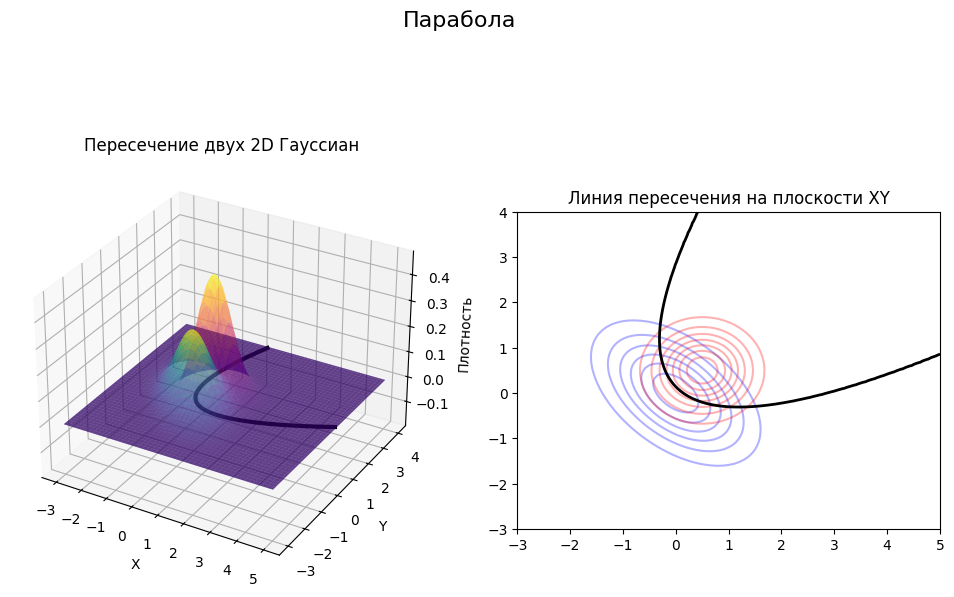

In [10]:
mu1 = np.array([0, 0])
cov1 = np.array([[2/3, -1/3], [-1/3, 2/3]])

mu2 = np.array([1/2, 1/2])
cov2 = np.array([[1/3, 0], [0, 1/3]])

print_two_gaussians(cov1, cov2, mu1, mu2, "Парабола")

Для эллипса:
$\Sigma_1 = \begin{vmatrix} 1 & 0 \\ 0 & 1 \end{vmatrix}$

$\Sigma_2 = \begin{vmatrix} 2 & 0 \\ 0 & 2 \end{vmatrix}$

$\Sigma_1^{-1} = \begin{vmatrix} 1 & 0 \\ 0 & 1 \end{vmatrix}$

$\Sigma_2^{-1} = \begin{vmatrix} 1/2 & 0 \\ 0 & 1/2 \end{vmatrix}$

Откуда $\det(\Sigma_1^{-1} - \Sigma_2^{-1}) = \det(\begin{vmatrix} 1/2 & 0 \\ 0 & 1/2 \end{vmatrix}) = 1/4 > 0$

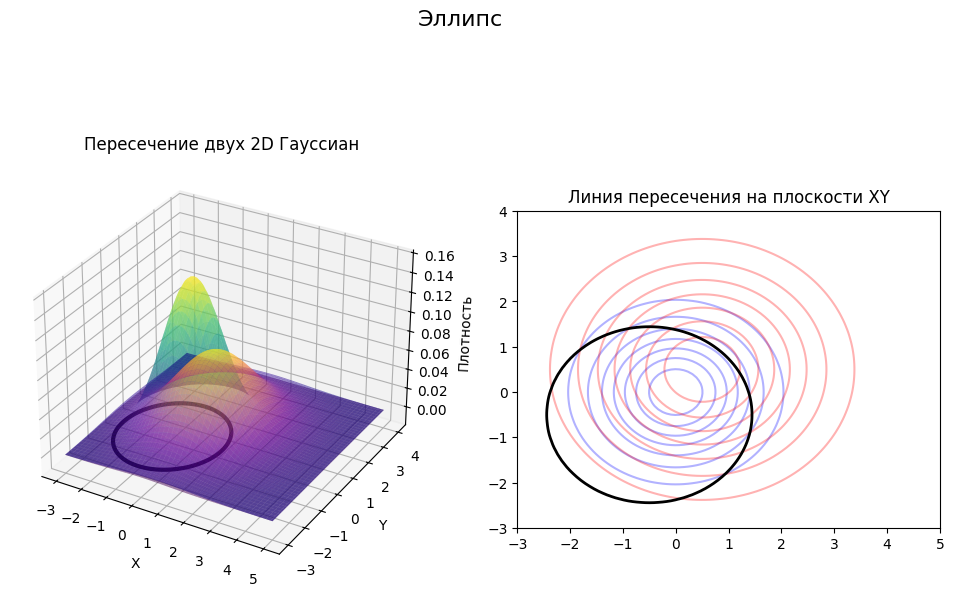

In [11]:
mu1 = np.array([0, 0])
cov1 = np.array([[1, 0], [0, 1]])

mu2 = np.array([1/2, 1/2])
cov2 = np.array([[2, 0], [0, 2]])

print_two_gaussians(cov1, cov2, mu1, mu2, "Эллипс")

Для двух параллельных прямых:$\Sigma_1 = \begin{vmatrix} 1 & 0 \\ 0 & 1 \end{vmatrix}$

$\Sigma_2 = \begin{vmatrix} 2/3 & -1/3 \\ -1/3 & 2/3 \end{vmatrix}$

$\Sigma_1^{-1} = \begin{vmatrix} 1 & 0 \\ 0 & 1 \end{vmatrix}$

$\Sigma_2^{-1} = \begin{vmatrix} 2 & 1 \\ 1 & 2 \end{vmatrix}$

Откуда $\det(\Sigma_1^{-1} - \Sigma_2^{-1}) = \det(\begin{vmatrix} -1 & -1 \\ -1 & -1 \end{vmatrix}) = 0$

Квадратичная форма $x^T A x$ сводится к $-(x_1 + x_2)^2$, поэтому мы получим 2 прямые $x_1 + x_2 = const_1$ и $x_1 + x_2 = const_2$, поэтому это 2 прямые а не парабола.
$$-(x_1 + x_2)^2 + 3(x_1 + x_2) + C = 0$$ получится если раскрыть скобки и посчитать по формуле выше. Тогда заменой $x_1 + x_2 = u$ получаем -u^2 + 3u + C = 0

Откуда получим два решения $x_1 + x_2 = Const_1, Const_2$

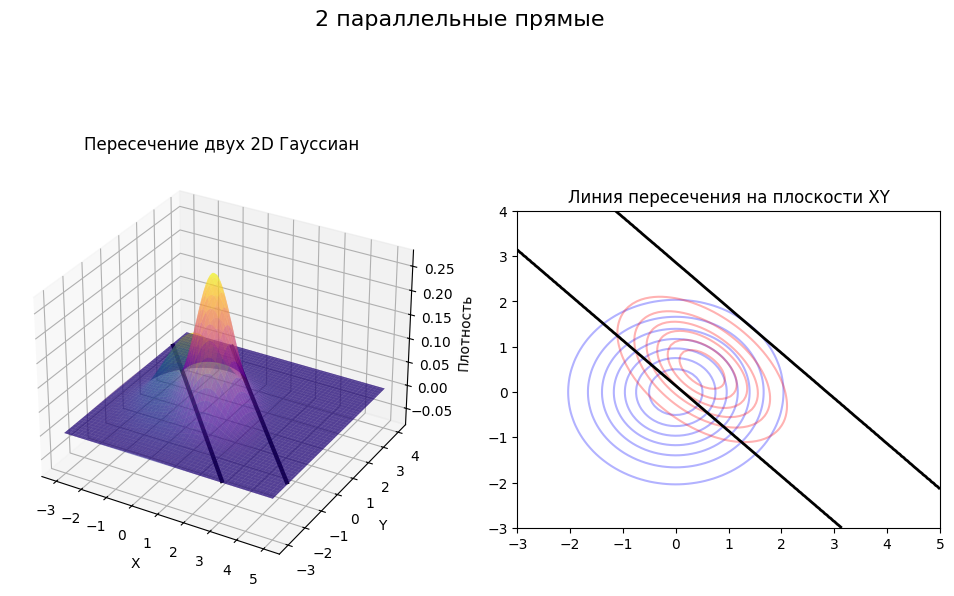

In [12]:
mu1 = np.array([0, 0])
cov1 = np.array([[1, 0], [0, 1]])

mu2 = np.array([1/2, 1/2])
cov2 = np.array([[2/3, -1/3], [-1/3, 2/3]])

print_two_gaussians(cov1, cov2, mu1, mu2, "2 параллельные прямые")

Для гиперболы:$\Sigma_1 = \begin{vmatrix} 1/2 & 0 \\ 0 & 1/2 \end{vmatrix}$

$\Sigma_2 = \begin{vmatrix} 2/3 & -1/3 \\ -1/3 & 2/3 \end{vmatrix}$

$\Sigma_1^{-1} = \begin{vmatrix} 2 & 0 \\ 0 & 2 \end{vmatrix}$

$\Sigma_2^{-1} = \begin{vmatrix} 2 & 1 \\ 1 & 2 \end{vmatrix}$

Откуда $\det(\Sigma_1^{-1} - \Sigma_2^{-1}) = \det(\begin{vmatrix} 0 & -1 \\ -1 & 0 \end{vmatrix}) = -1 < 0$

$x^T W x + v^T x + C = 0$, где $W = \begin{pmatrix} -1/2 & 0 \\ 0 & 1/2 \end{pmatrix}$, $v = -2(\Sigma_1^{-1}\mu_1 - \Sigma_2^{-1}\mu_2)$

$$C = \mu_1^T \Sigma_1^{-1} \mu_1 - \mu_2^T \Sigma_2^{-1} \mu_2 = 0 - \begin{pmatrix} 1/2 & 1/2 \end{pmatrix} \begin{pmatrix} 1/2 \\ 1/4 \end{pmatrix} = -\left(\frac{1}{4} + \frac{1}{8}\right) = -\frac{3}{8}$$

Тогде уравнение принимает вид: $$-\frac{1}{2}x_1^2 + \frac{1}{2}x_2^2 + x_1 + \frac{1}{2}x_2 - \frac{3}{8} = 0$$
Умножим на 2:
$$x_1^2 - x_2^2 - 2x_1 - x_2 + \frac{3}{4} = 0$$

Разложим на множители.

$$(x_1 - 1 - x_2 - 0.5)(x_1 - 1 + x_2 + 0.5) = 0$$

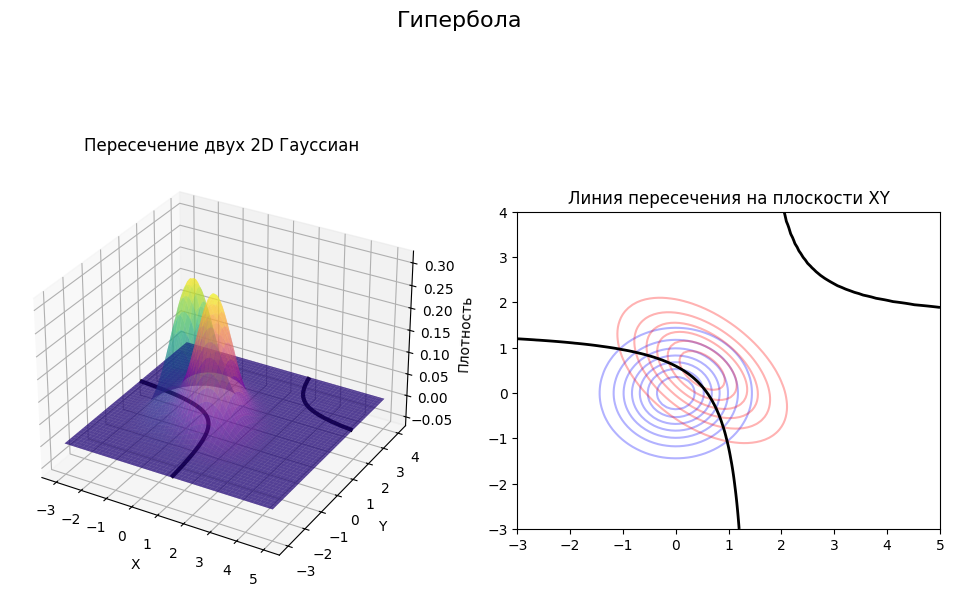

In [13]:
mu1 = np.array([0, 0])
cov1 = np.array([[1/2, 0], [0, 1/2]])

mu2 = np.array([1/2, 1/2])
cov2 = np.array([[2/3, -1/3], [-1/3, 2/3]])

print_two_gaussians(cov1, cov2, mu1, mu2, "Гипербола")

$\Sigma_1 = \begin{vmatrix} 2 & 0 \\ 0 & 1 \end{vmatrix}$

$\Sigma_2 = \begin{vmatrix} 1 & 0 \\ 0 & 2 \end{vmatrix}$

$\Sigma_1^{-1} = \begin{vmatrix} 1/2 & 0 \\ 0 & 1 \end{vmatrix}$

$\Sigma_2^{-1} = \begin{vmatrix} 1 & 0 \\ 0 & 1/2 \end{vmatrix}$

Откуда $\det(\Sigma_1^{-1} - \Sigma_2^{-1}) = \det(\begin{vmatrix} -1/2 & 0 \\ 0 & 1/2 \end{vmatrix}) = -1/4 < 0$

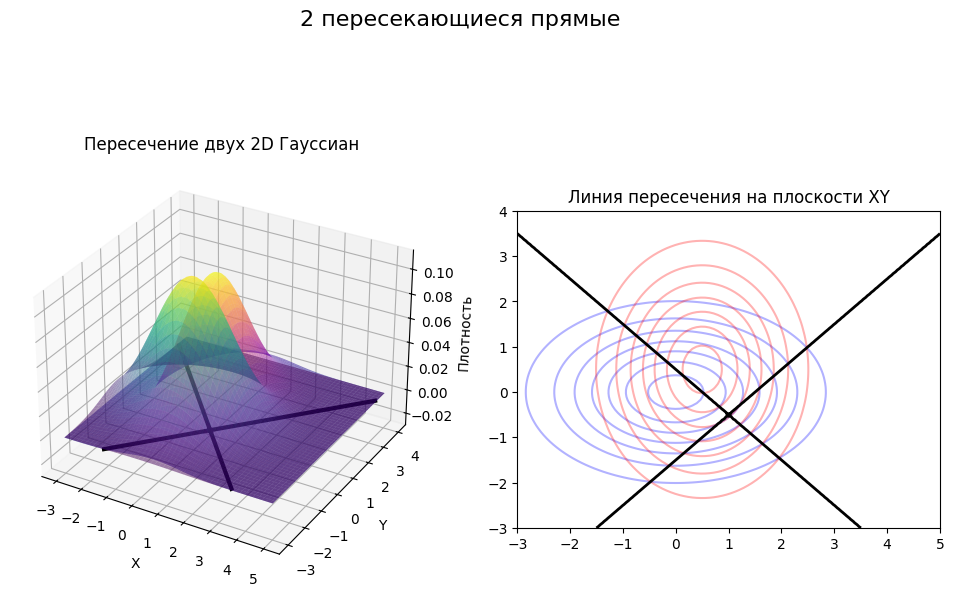

In [14]:
mu1 = np.array([0, 0])
cov1 = np.array([[2, 0], [0, 1]])

mu2 = np.array([1/2, 1/2])
cov2 = np.array([[1, 0], [0, 2]])

print_two_gaussians(cov1, cov2, mu1, mu2, "2 пересекающиеся прямые")

---
© 2026 команда <a href="https://thetahat.ru/">ThetaHat</a> для ВвАД